# Ensemble Plotting Notebook

This notebook plots ensemble results from JSON/NPZ files.

**Works with both local and cluster runs:**
- **Local runs:** `ensemble.run_local()` automatically saves JSON/NPZ files
- **Cluster runs:** `python scripts/analyze_ensemble.py` generates the same JSON/NPZ files

**Required files in ensemble directory:**
- `ensemble_statistics.json` (basic statistics)
- `ensemble_config.json` (configuration)
- `ensemble_structural.npz` (optional, for structural plots)

**Save paths:**
- Single-ensemble plots are saved to `<ENSEMBLE_DIR>/Plots/`
- Comparison plots are saved to `Plots_Comparison_<Label1>_<Label2>_.../`


## 1. Imports

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import qtft.analysis as analysis
import qtft.plotting as plotting

print("Analysis and plotting modules loaded")


Analysis and plotting modules loaded


## 2. Configuration

In [2]:
# Base directory containing ensemble results
BASE_DIR = "Different_Particle_Ratios"

# Path to ensemble results directory
# Examples of auto-generated folder names:
#   - "200Qt_400Ft_dt10ps_30us/"           (no name)
#   - "test_200Qt_400Ft_dt10ps_30us/"      (name='test')

ENSEMBLE_DIR = os.path.join(BASE_DIR, "200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us")


## 3. Load Data

In [3]:
# Load all ensemble data
stats, structural, config = analysis.load_ensemble_data(ENSEMBLE_DIR)

# Create Plots directory inside ensemble directory
PLOTS_DIR = os.path.join(ENSEMBLE_DIR, "Plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR}/")

print(f"\nLoaded ensemble with {stats.get('n_replicas', 'unknown')} replicas")
print(f"Time points: {len(stats.get('times', []))}")
print(f"Structural data keys: {list(structural.keys()) if structural else 'None'}")


✓ Loaded statistics from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_statistics.json
✓ Loaded structural data from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_structural.npz
✓ Loaded configuration from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_config.json
Plots will be saved to: Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/

Loaded ensemble with 10 replicas
Time points: 20001
Structural data keys: ['times', 'n_replicas', 'available_replicas', 'bonds_mean', 'bonds_std', 'bonds_all', 'energy_mean', 'energy_std', 'energy_all', 'pressure_mean', 'pressure_std', 'pressure_all', 'n_clusters_mean', 'n_clusters_std', 'n_clusters_all', 'largest_cluster_mean', 'largest_cluster_std', 'largest_cluster_all', 'fraction_bound_mean', 'fraction_bound_std', 'fraction_bound_all', 'avg_cluster_mean', 'avg_cluster_std', 'avg

## 4. Print Summary

In [4]:
analysis.print_ensemble_summary(stats, config)


ENSEMBLE SUMMARY (N=10 replicas)

System: 200 Qt + 400 Ft particles

Final state metrics:
  Bonds: 596.6 ± 1.3
  Largest cluster: 65.4% ± 19.0% of particles
  Half-time: 7.84 ± 0.24 µs



## 5. Plot Ensemble Observables


Generating ensemble observable plots...
✓ Saved plot to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/ensemble_observables.svg


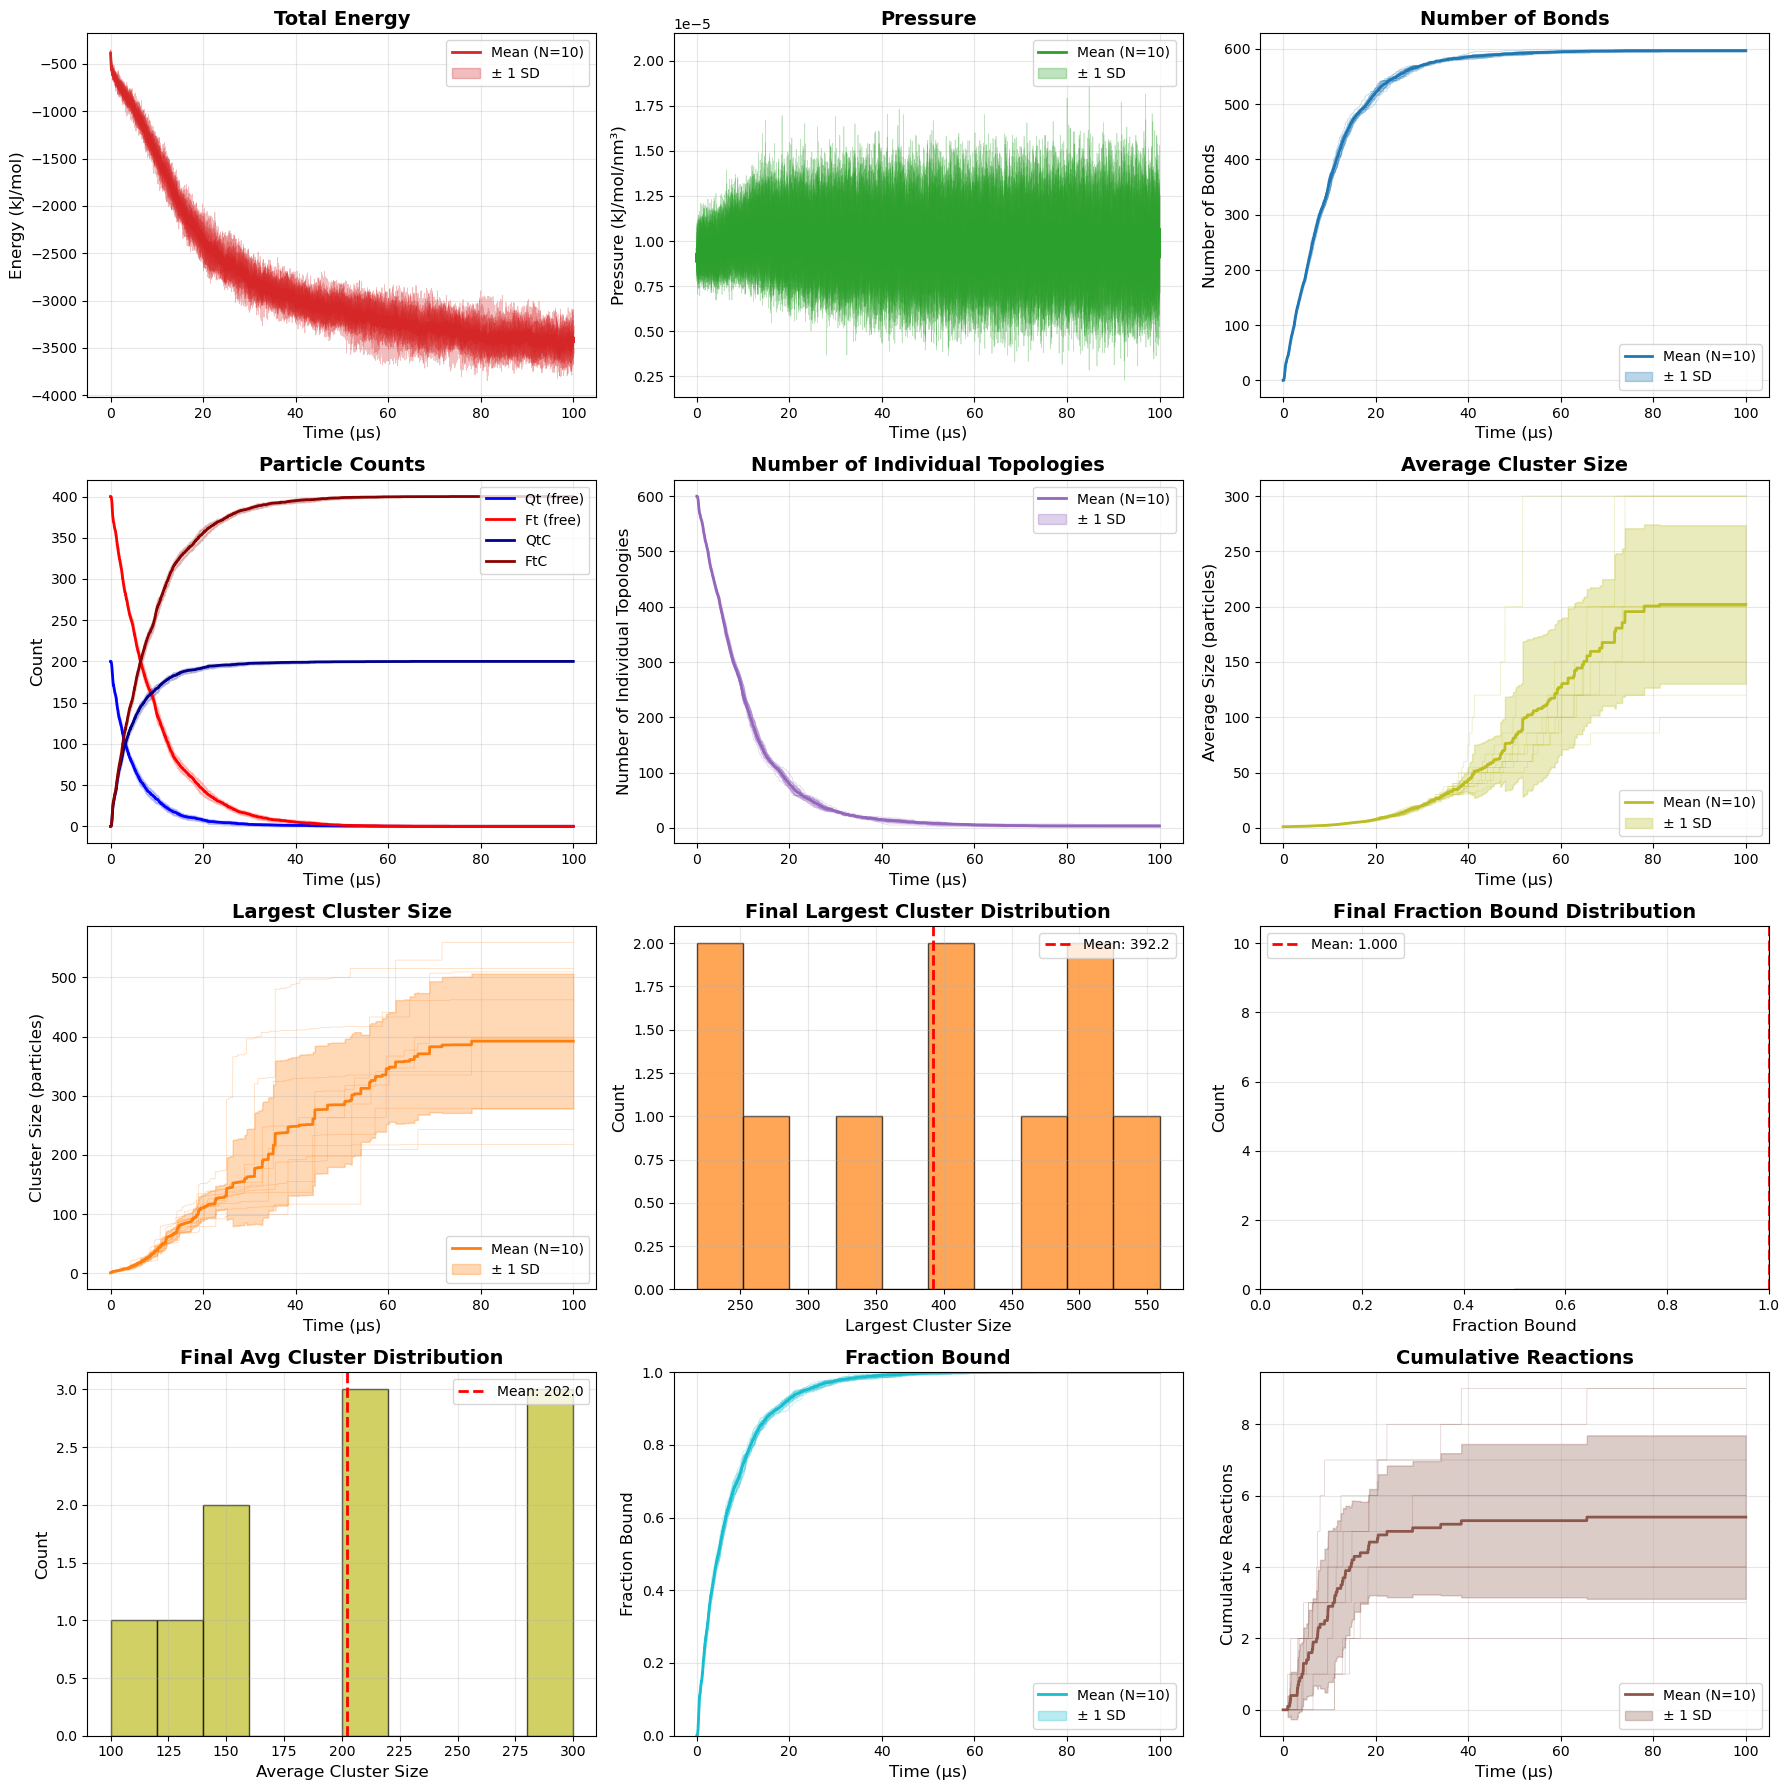

In [6]:
fig = plotting.plot_ensemble_observables(
    stats,
    config,
    structural=structural,
    show_individual=True,
    save_path=os.path.join(PLOTS_DIR, "ensemble_observables.svg"),
)
plt.show()


## 6. Plot Structural Analysis


Generating structural ensemble plots...
✓ Saved plot to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/ensemble_structural.svg


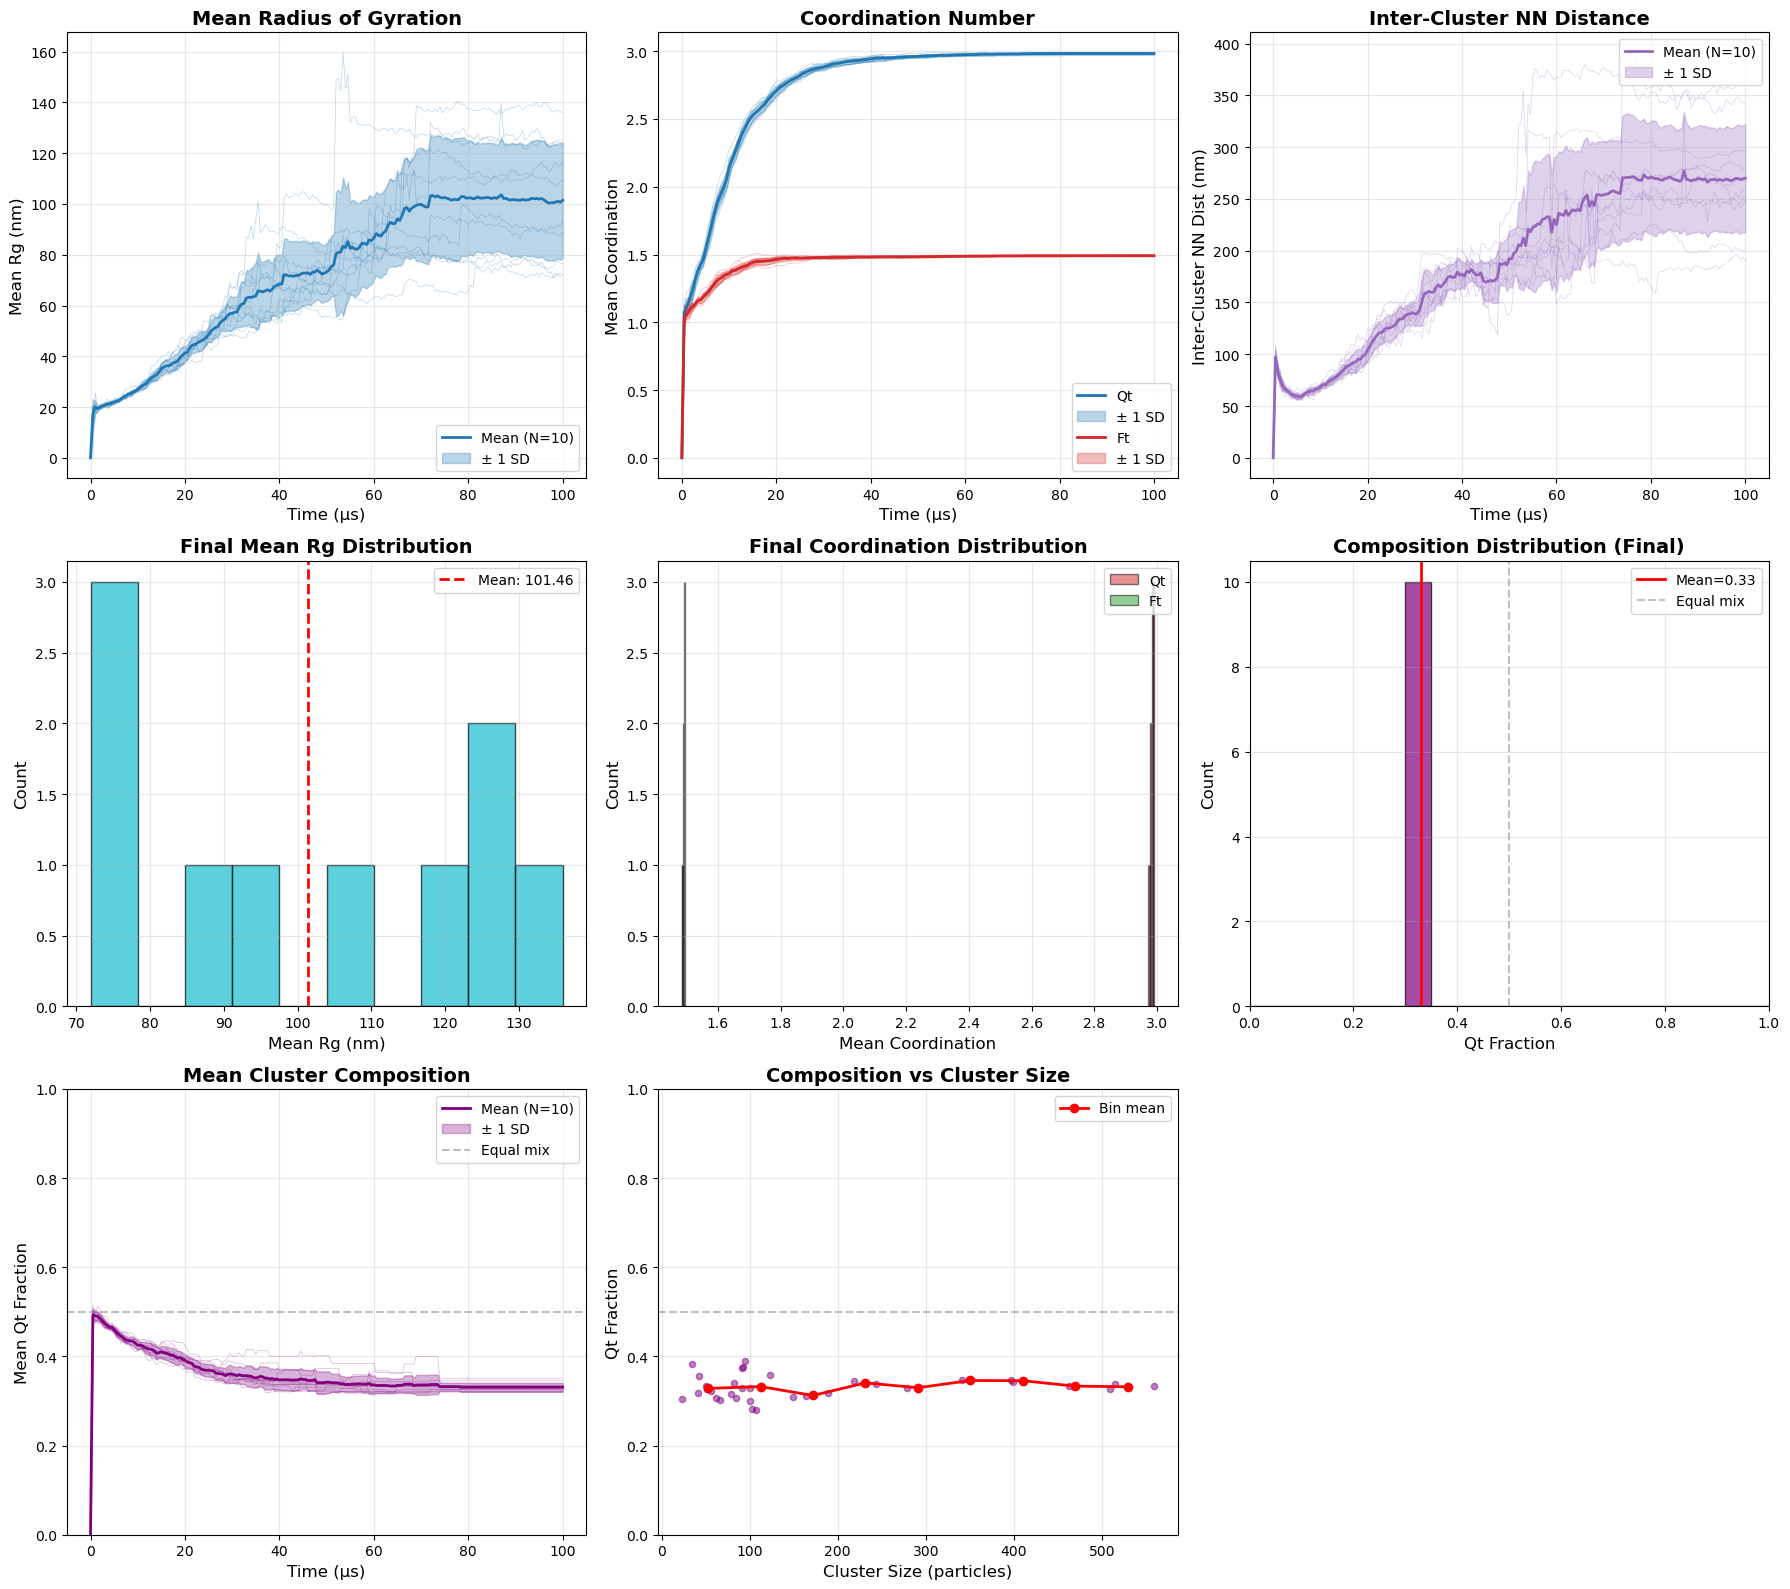

In [6]:
if structural:
    fig = plotting.plot_ensemble_structural(
        stats,
        structural,
        config,
        show_individual=True,
        save_path=os.path.join(PLOTS_DIR, "ensemble_structural.svg"),
    )
    plt.show()
else:
    print("No structural data available")


## 6b. Size Category Analysis

Plot the fraction of particles in each size category (monomers, small, medium, large, very large) over time.
Categories are adaptive based on total particle count.

✓ Saved plot to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/ensemble_size_categories.svg


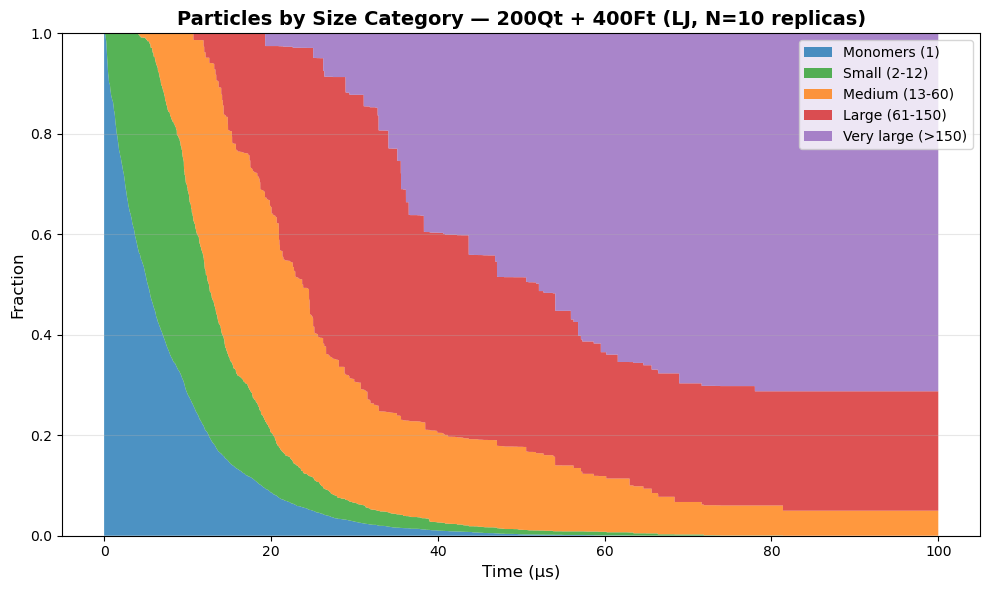

In [7]:
if structural and 'size_fractions_times' in structural:
    fig = plotting.plot_ensemble_size_categories(
        stats,
        structural,
        config,
        save_path=os.path.join(PLOTS_DIR, "ensemble_size_categories.svg"),
    )
    plt.show()
else:
    print("No size fraction data available.")
    print("Re-run ensemble analysis to compute size fractions.")

## 6c. Thesis Ensemble Panel

Composite 4×3 figure combining the key ensemble plots for the thesis, saved as SVG and PNG into `PLOTS_DIR`.


Generating ensemble thesis panel...
✓ Saved panel to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/ensemble_panel.svg
✓ Saved panel to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/ensemble_panel.png


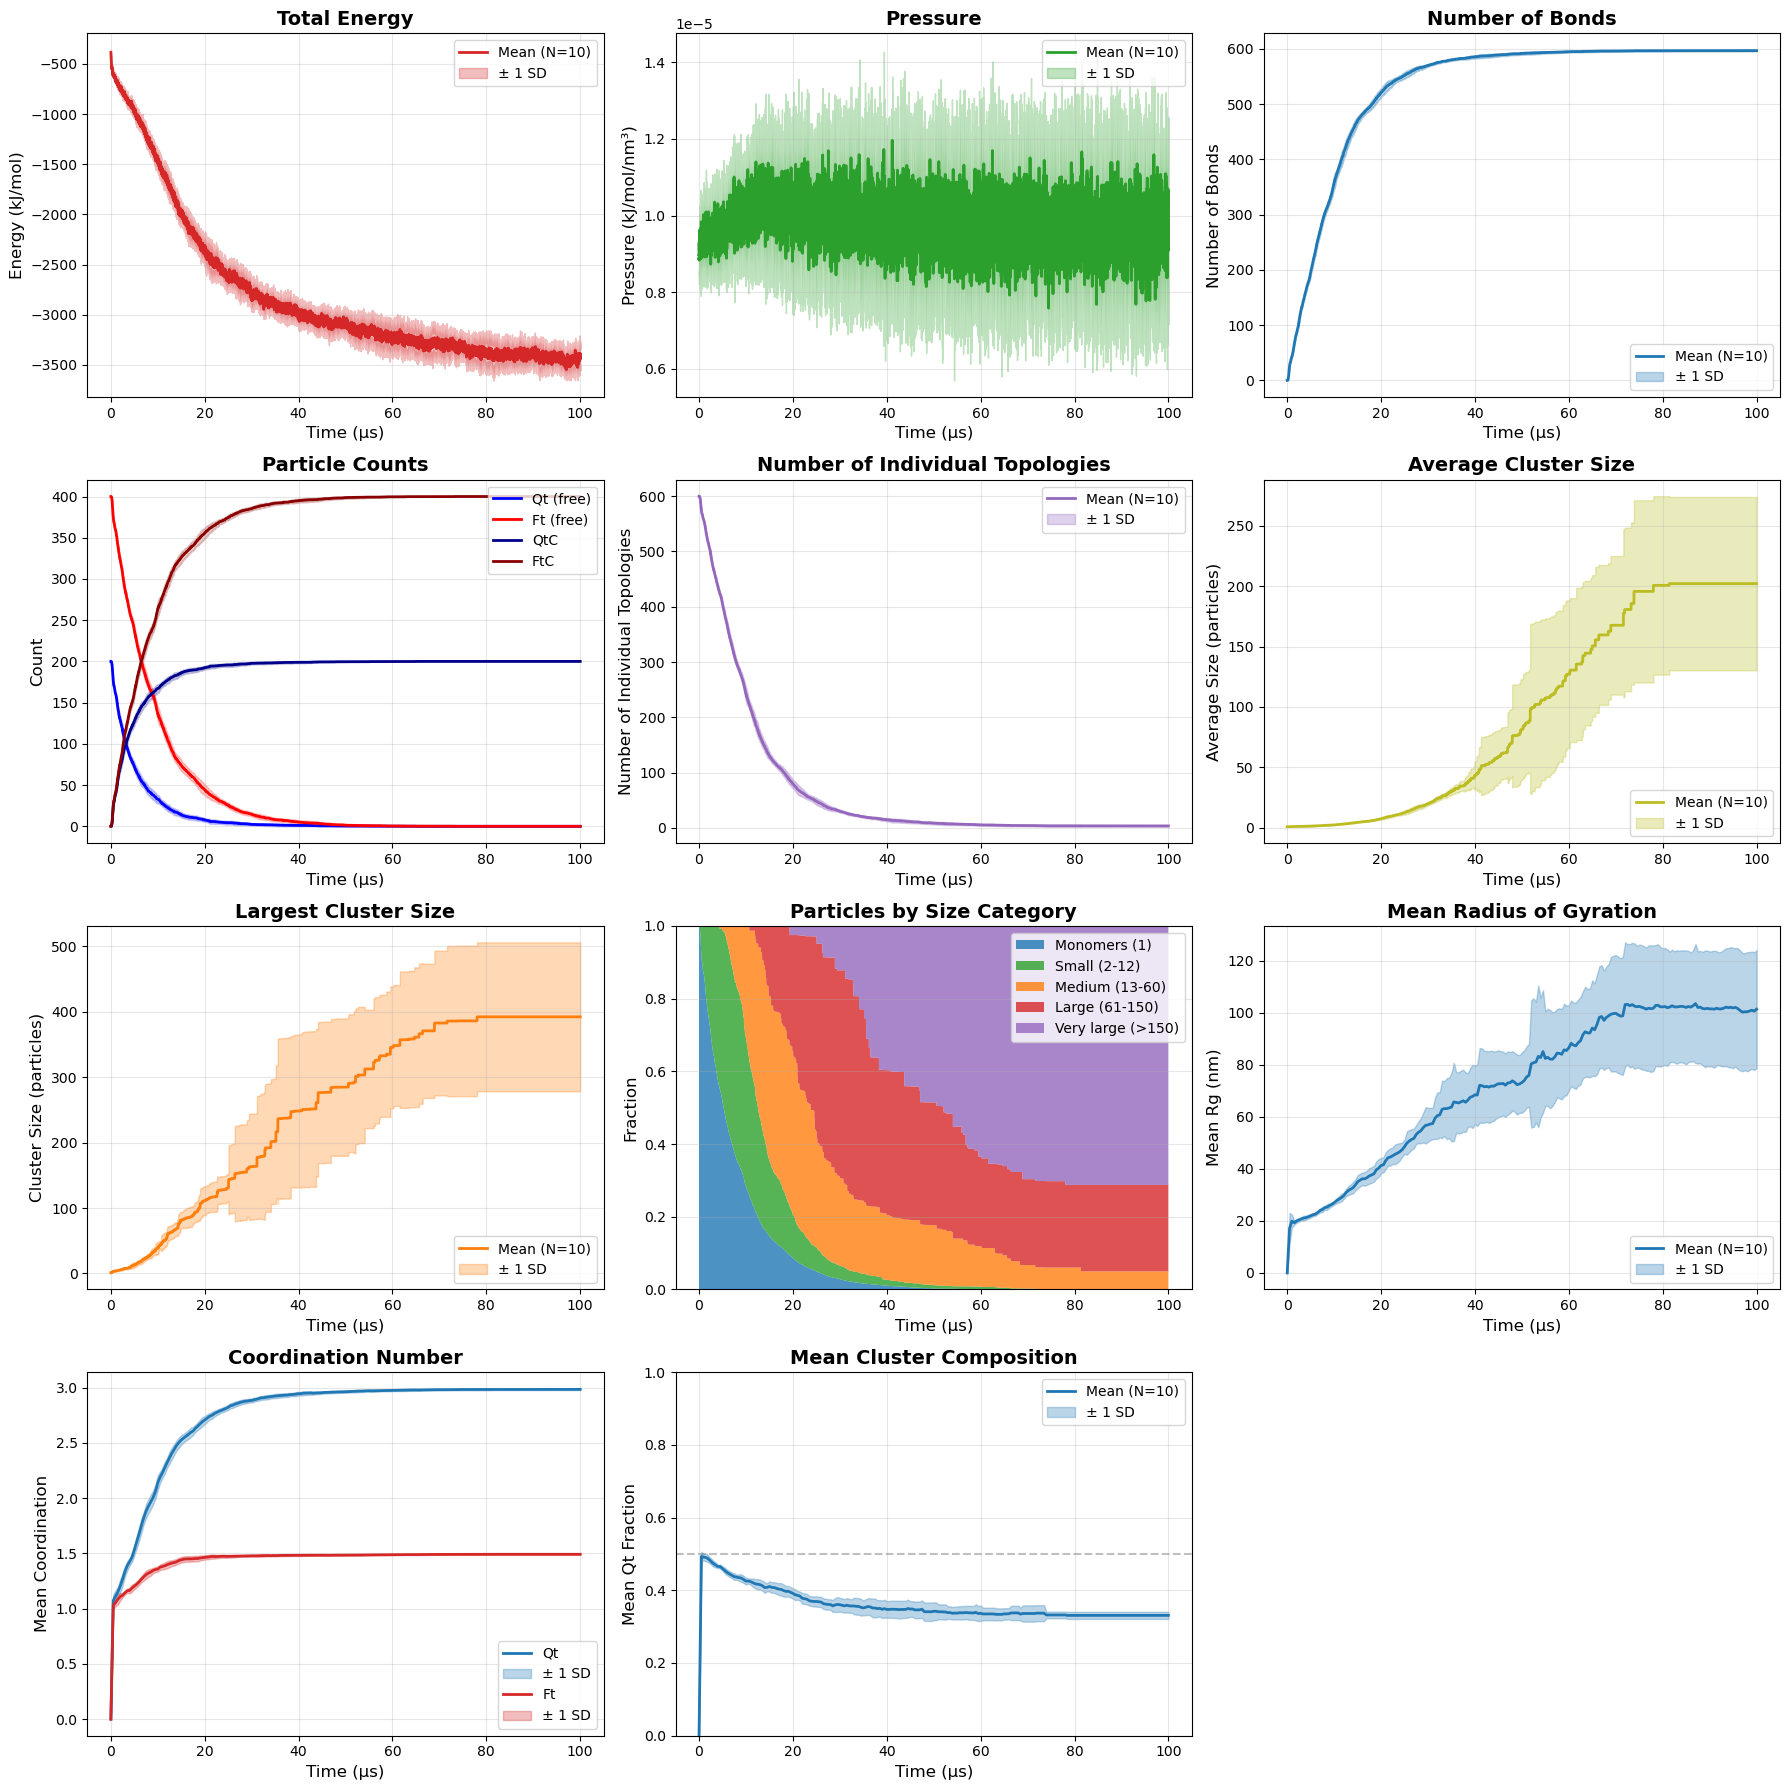

In [5]:
import qtft.plot_ensemble_panel as panel

fig = panel.plot_ensemble_panel(
    stats,
    structural,
    config,
    show_individual=False,
    save_path_base=os.path.join(PLOTS_DIR, "ensemble_panel"),
)
plt.show()

## 7. Custom Plots

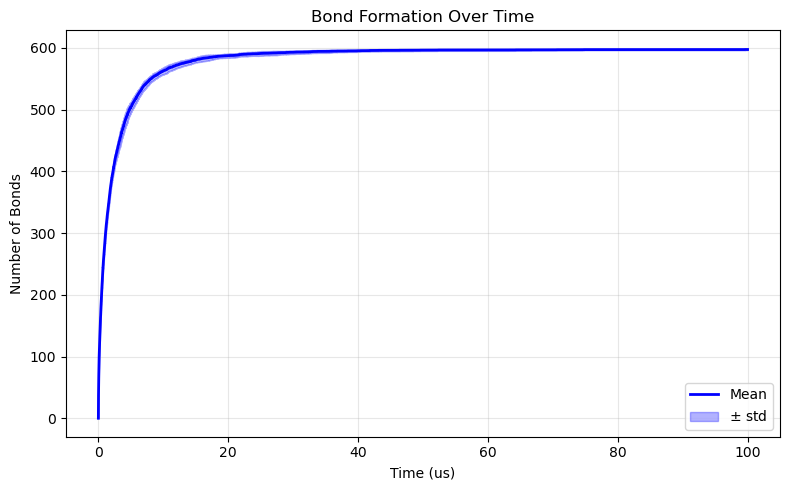

In [9]:
# Example: Custom bond count plot
if 'bonds_mean' in stats and 'times' in stats:
    times = stats['times']
    timestep = config.get('timestep', 0.001)
    times_us = times * timestep * 1e-3  # Convert to microseconds
    
    plt.figure(figsize=(8, 5))
    plt.plot(times_us, stats['bonds_mean'], 'b-', linewidth=2, label='Mean')
    if 'bonds_std' in stats:
        plt.fill_between(times_us,
                        stats['bonds_mean'] - stats['bonds_std'],
                        stats['bonds_mean'] + stats['bonds_std'],
                        alpha=0.3, color='blue', label='$\pm$ std')
    plt.xlabel('Time (us)')
    plt.ylabel('Number of Bonds')
    plt.title('Bond Formation Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Export Data

In [9]:
# Export time series to CSV
import pandas as pd

if 'times' in stats and 'bonds_mean' in stats:
    timestep = config.get('timestep', 0.001)
    df = pd.DataFrame({
        'time_steps': stats['times'],
        'time_us': stats['times'] * timestep * 1e-3,
        'bonds_mean': stats['bonds_mean'],
        'bonds_std': stats.get('bonds_std', np.zeros_like(stats['bonds_mean'])),
    })
    csv_path = os.path.join(PLOTS_DIR, 'ensemble_bonds.csv')
    df.to_csv(csv_path, index=False)
    print(f'Saved to {csv_path}')


Saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/Plots/ensemble_bonds.csv


---
# Ensemble Comparison

Compare multiple ensemble runs with different simulation conditions.

**Workflow:**
1. Run multiple ensemble simulations with different parameters
2. Run `python scripts/analyze_ensemble.py` for each ensemble to generate JSON/NPZ files
3. Either:
   - Run `python scripts/analyze_ensemble.py compare` to generate comparison data, OR
   - Load ensembles directly in this notebook
4. Plot comparison results using `qtft.plotting` functions

## 9. Comparison Configuration

In [6]:
# Base directory containing all ensemble directories
BASE_DIR = "Different_Particle_Ratios"

# Define ensembles to compare
# Format: {"Label": "path/to/ensemble_directory/"}
# Note: Folder names now include potential type and epsilon values, e.g.:
#   200Qt_400Ft_WCA_eQQ7_eFF7_eQF7_kon175_dt10ps_59us
ENSEMBLES_TO_COMPARE = {
    "200 Qt 200 Ft": os.path.join(BASE_DIR, "200Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
    "200 Qt 400 Ft": os.path.join(BASE_DIR, "200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
    "200 Qt 1000 Ft": os.path.join(BASE_DIR, "200Qt_1000Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
    "400 Qt 200 Ft": os.path.join(BASE_DIR, "400Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
    "600 Qt 50 Ft": os.path.join(BASE_DIR, "600Qt_50Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
    "600 Qt 200 Ft": os.path.join(BASE_DIR, "600Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
}


# Alternatively, load pre-computed comparison data:
# COMPARISON_DIR = "comparison_results/"

## 10. Load Ensembles for Comparison

In [8]:
import qtft.comparison as ae

# Option 1: Load ensembles directly from directories
comparison = ae.compare_ensembles(ENSEMBLES_TO_COMPARE)

# Option 2: Load pre-computed comparison data (uncomment if using)
# comparison = ae.load_comparison_data(COMPARISON_DIR)

# Create comparison Plots directory inside BASE_DIR
# e.g., "Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_400Qt200Ft"
_sanitized_labels = [l.replace(' ', '') for l in comparison['labels']]
COMPARISON_PLOTS_DIR = os.path.join(BASE_DIR, "Plots_Comparison_" + "_".join(_sanitized_labels))
os.makedirs(COMPARISON_PLOTS_DIR, exist_ok=True)
print(f"\nComparison plots will be saved to: {COMPARISON_PLOTS_DIR}/")


LOADING ENSEMBLES FOR COMPARISON

Loading: 200 Qt 200 Ft
  Directory: Different_Particle_Ratios/200Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us
  ✓ Loaded 10 replicas, 20001 time points (with structural data)

Loading: 200 Qt 400 Ft
  Directory: Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us
  ✓ Loaded 10 replicas, 20001 time points (with structural data)

Loading: 200 Qt 1000 Ft
  Directory: Different_Particle_Ratios/200Qt_1000Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us
  ✓ Loaded 10 replicas, 20001 time points (with structural data)

Loading: 400 Qt 200 Ft
  Directory: Different_Particle_Ratios/400Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us
  ✓ Loaded 10 replicas, 20001 time points (with structural data)

Loading: 600 Qt 50 Ft
  Directory: Different_Particle_Ratios/600Qt_50Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us
  ✓ Loaded 10 replicas, 20001 time points (with structural data)

Loading: 600 Qt 200 Ft
  Directory: Different_

## 11. Parameter Differences

In [9]:
# Print parameter differences between ensembles
ae.print_parameter_differences(comparison)


PARAMETER DIFFERENCES

n_qt:
  200 Qt 200 Ft: 200
  200 Qt 400 Ft: 200
  200 Qt 1000 Ft: 200
  400 Qt 200 Ft: 400
  600 Qt 50 Ft: 600
  600 Qt 200 Ft: 600

n_ft:
  200 Qt 200 Ft: 200
  200 Qt 400 Ft: 400
  200 Qt 1000 Ft: 1000
  400 Qt 200 Ft: 200
  600 Qt 50 Ft: 50
  600 Qt 200 Ft: 200


## 12. Comparison Summary Plot

/home/befe/readdySimulations/Qt_Ft_Simulation_16/qtft/plotting.py:2848: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/comparison_summary.svg


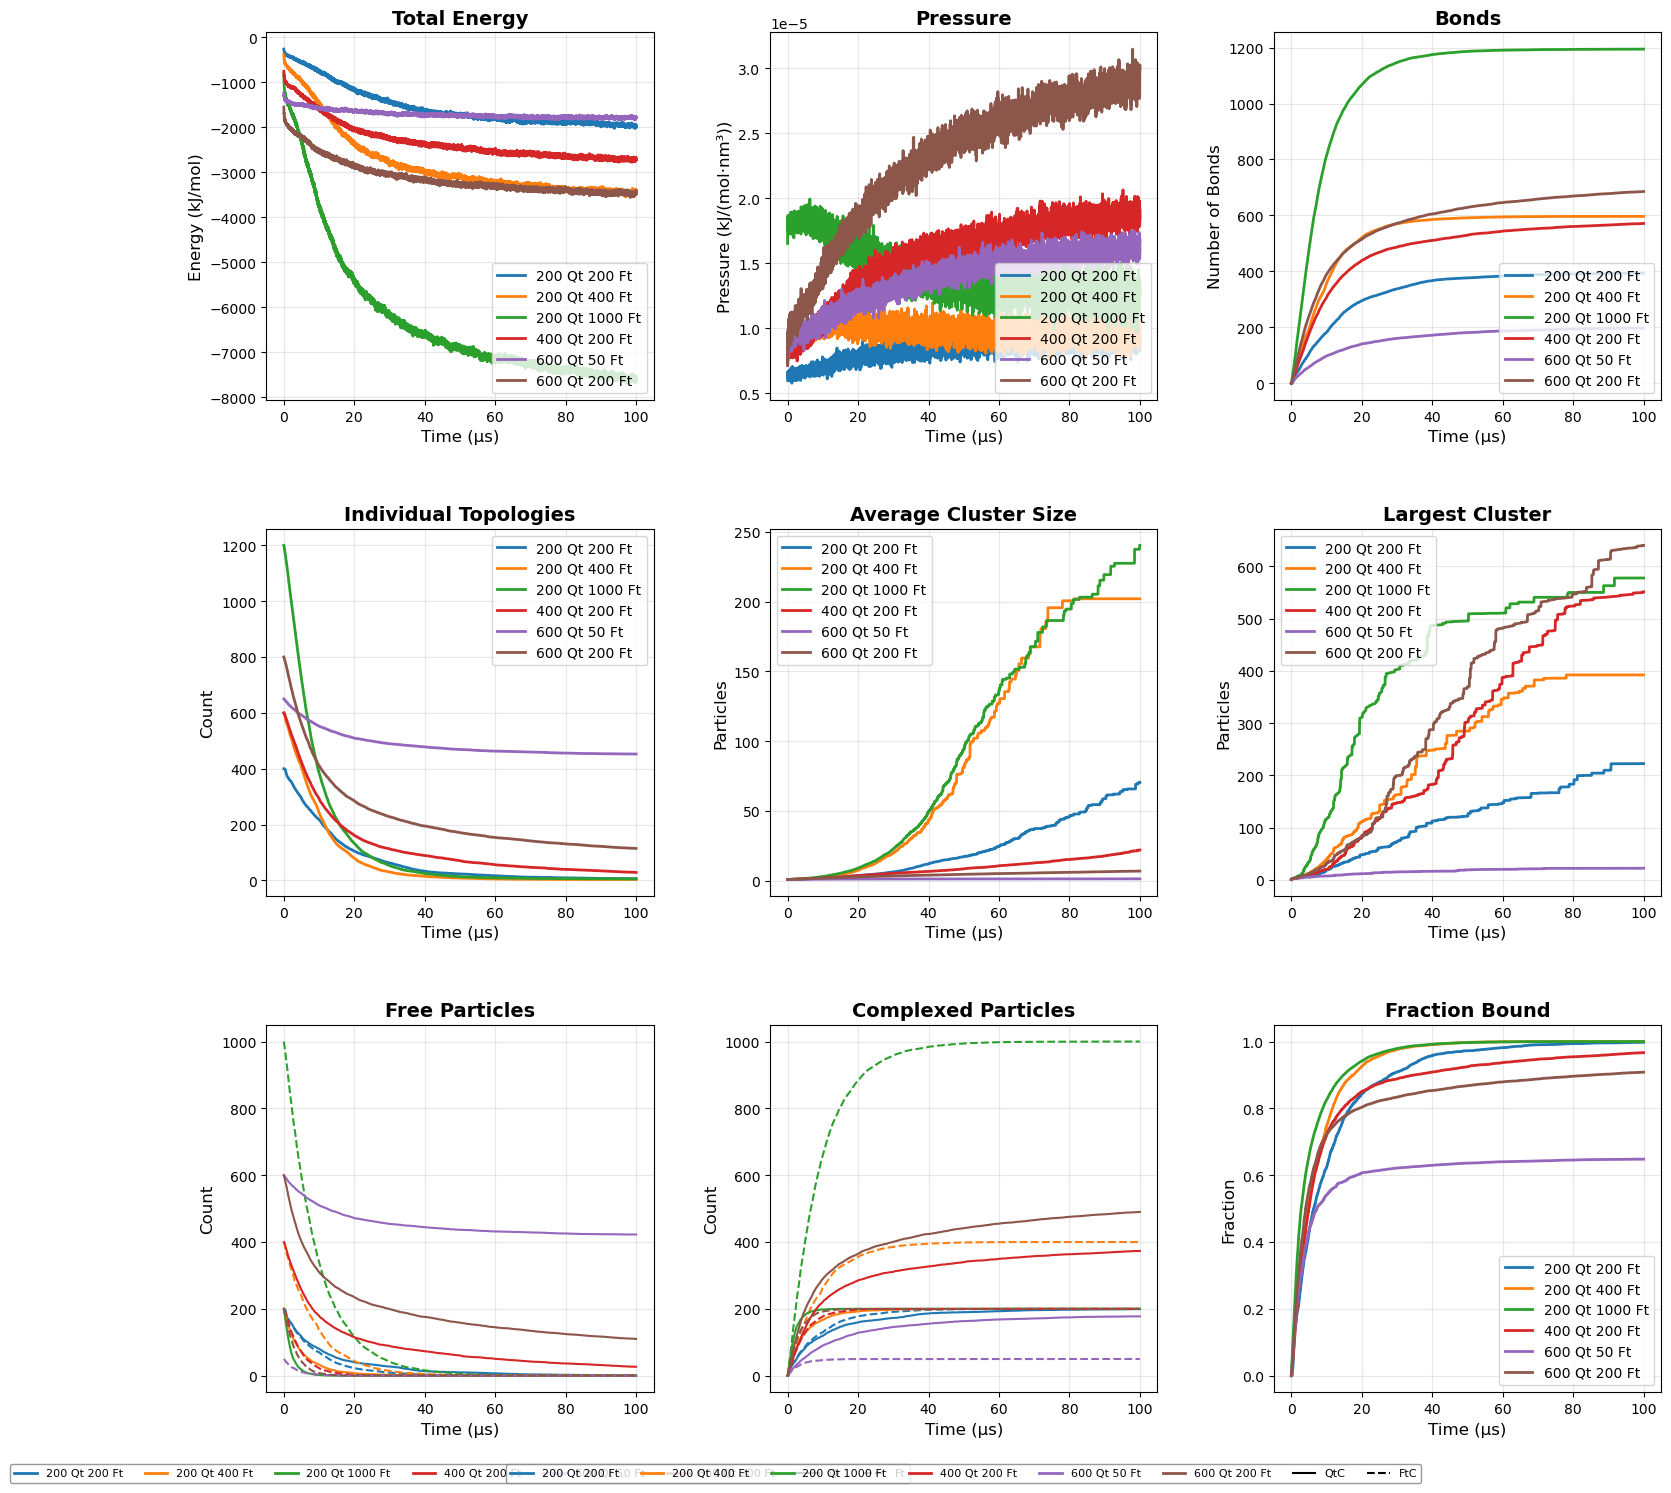

In [10]:
# Multi-panel summary comparison (3×3 grid of time-series)
# show_bands: True = show error bands, False = lines only, None = auto (True for ≤3 ensembles)
fig = plotting.plot_comparison_summary(
    comparison,
    show_bands=None,  # Auto-detect based on number of ensembles
    save_path=os.path.join(COMPARISON_PLOTS_DIR, "comparison_summary.svg"),
)
plt.show()


## 13. Final State Comparison (Bar Charts)


✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/comparison_final_state.svg


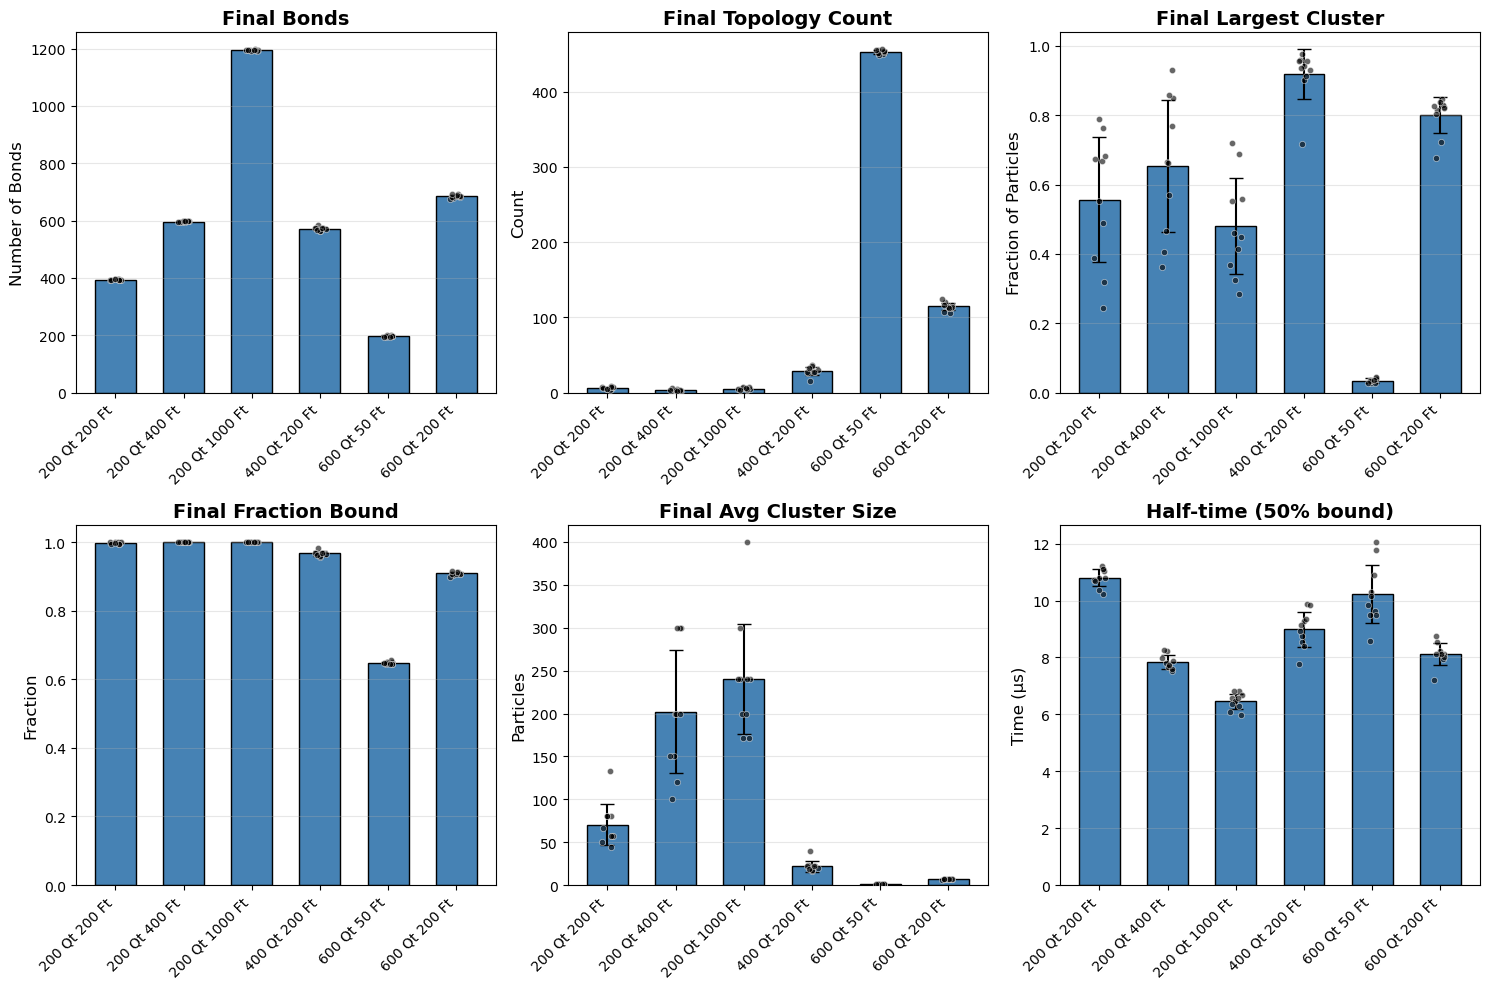

In [15]:
# Bar charts comparing final values across ensembles
# show_individual_points: True = overlay individual replica dots on bars
fig = plotting.plot_comparison_final_state(
    comparison,
    show_individual_points=True,
    save_path=os.path.join(COMPARISON_PLOTS_DIR, "comparison_final_state.svg"),
)
plt.show()


## 14. Structural Analysis Comparison


/home/befe/readdySimulations/Qt_Ft_Simulation_16/qtft/plotting.py:2667: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/comparison_structural.svg


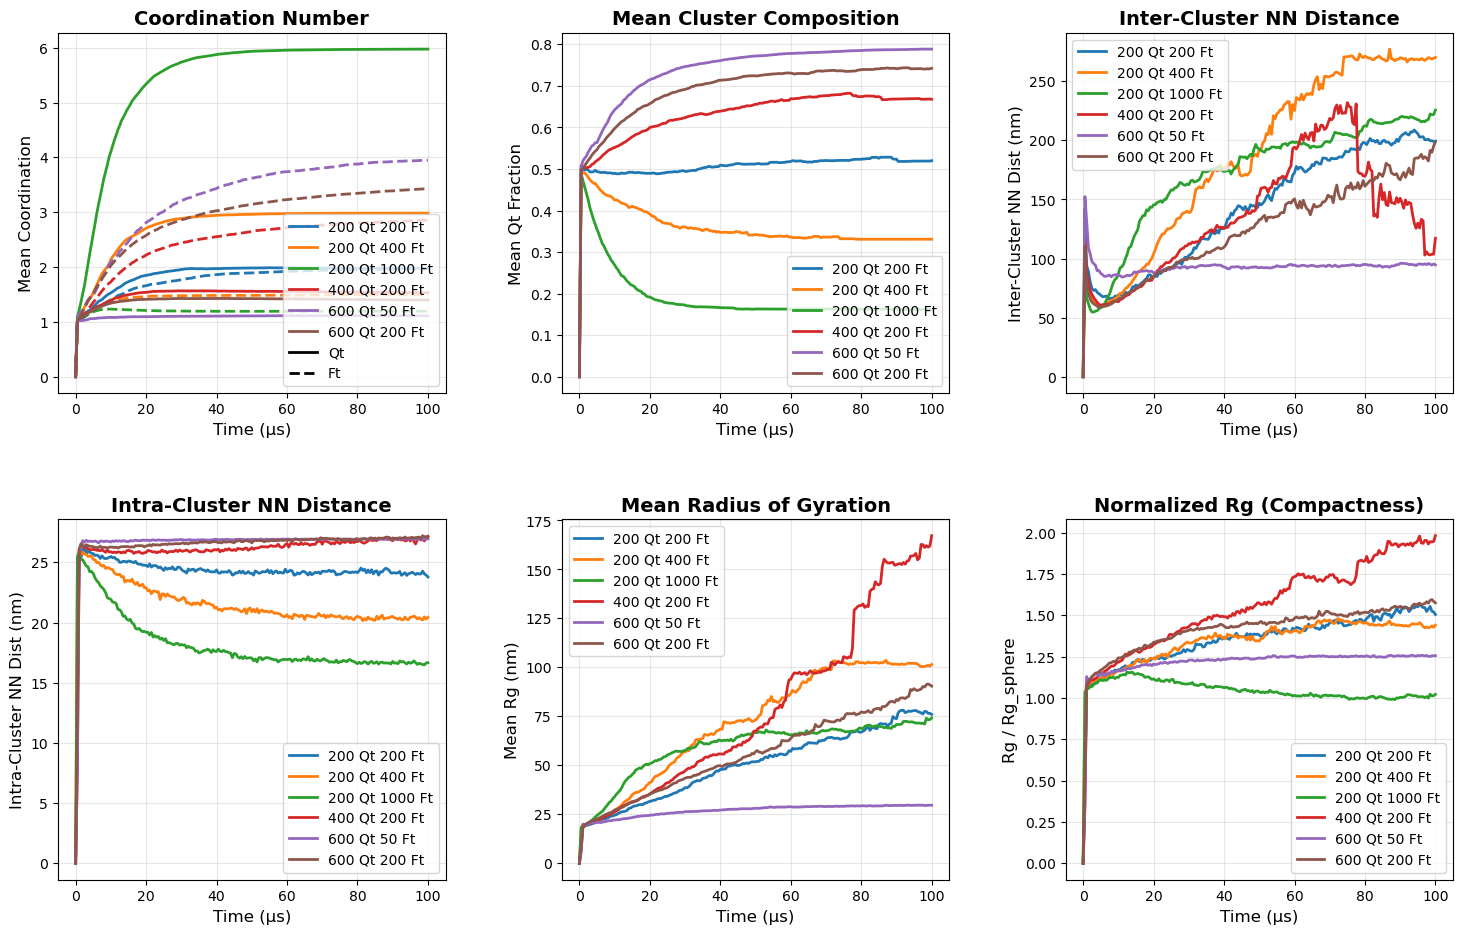

In [11]:
# Structural metrics comparison (2×3 grid)
# Requires  when loading ensembles
fig = plotting.plot_comparison_structural(
    comparison,
    show_bands=None,  # Auto-detect based on number of ensembles
    save_path=os.path.join(COMPARISON_PLOTS_DIR, "comparison_structural.svg"),
)
plt.show()


## 14c. Thesis Comparison Panel

Composite 3×3 figure overlaying all compared ensembles (one colored line each, ±1 SD bands).
Layout: Energy, Pressure, Bonds / Individual Topologies, Average Cluster Size, Largest Cluster /
Coordination Number, Mean Cluster Composition, Mean Radius of Gyration. Saved as SVG and PNG into
`COMPARISON_PLOTS_DIR`. Row 3 requires the live `compare_ensembles` load path (structural data).

In [ ]:
import qtft.plot_comparison_panel as cpanel

fig = cpanel.plot_comparison_panel(
    comparison,
    show_bands=None,  # Auto-detect: True for ≤3 ensembles, False otherwise
    save_path_base=os.path.join(COMPARISON_PLOTS_DIR, "comparison_panel"),
)
plt.show()


## 14b. Size Category Comparison

Plot particles by size category for each ensemble individually.
Each ensemble gets its own stacked area chart with adaptive category boundaries.

✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/size_categories_200_Qt_200_Ft.svg


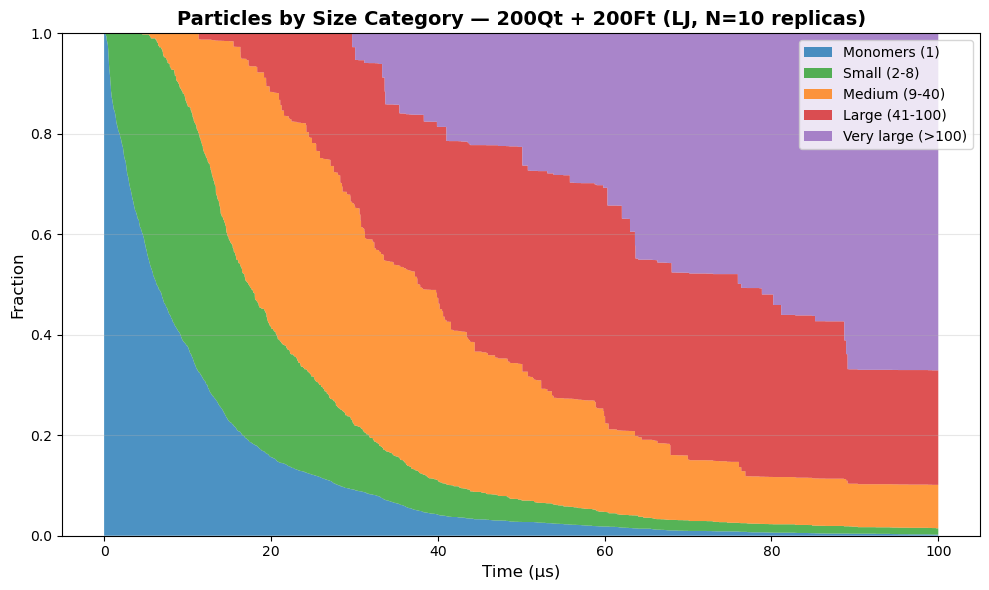

✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/size_categories_200_Qt_400_Ft.svg


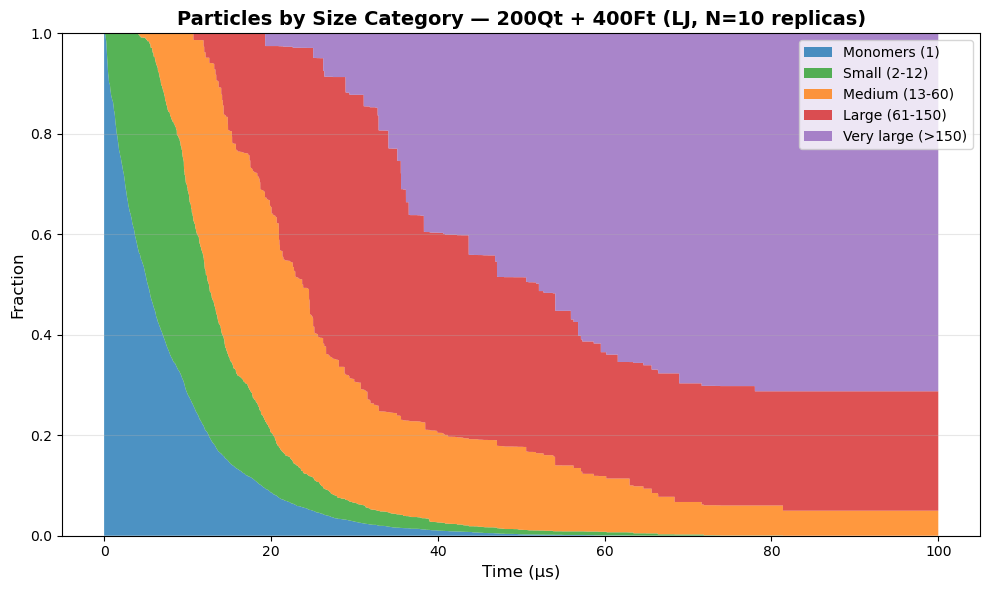

✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/size_categories_200_Qt_1000_Ft.svg


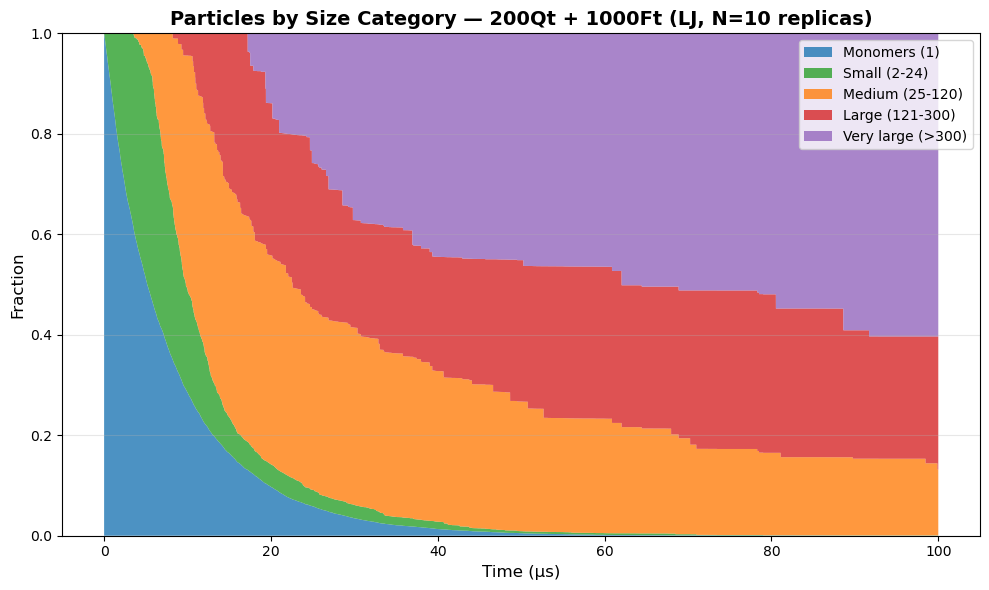

✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/size_categories_400_Qt_200_Ft.svg


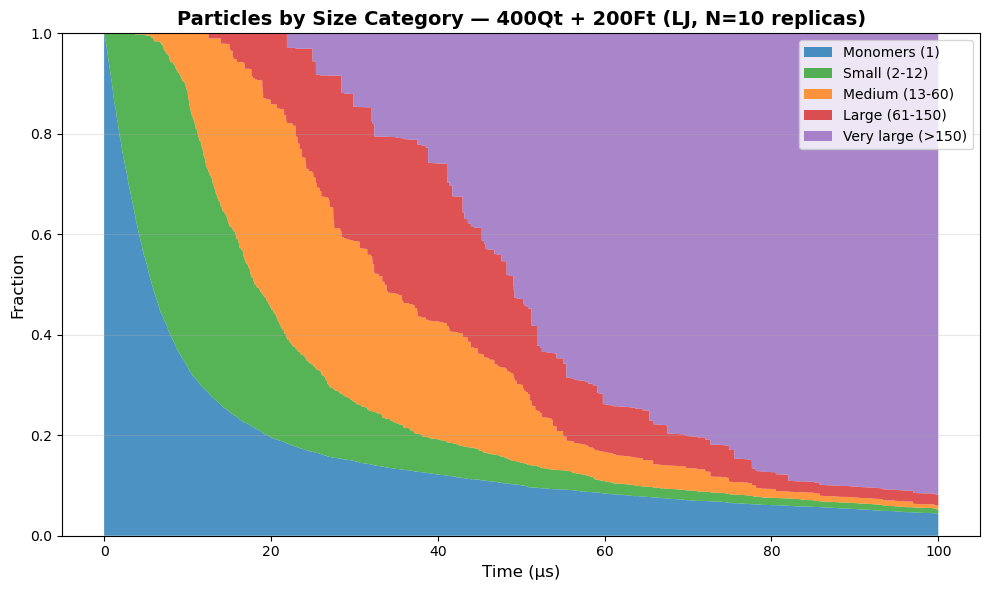

✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/size_categories_600_Qt_50_Ft.svg


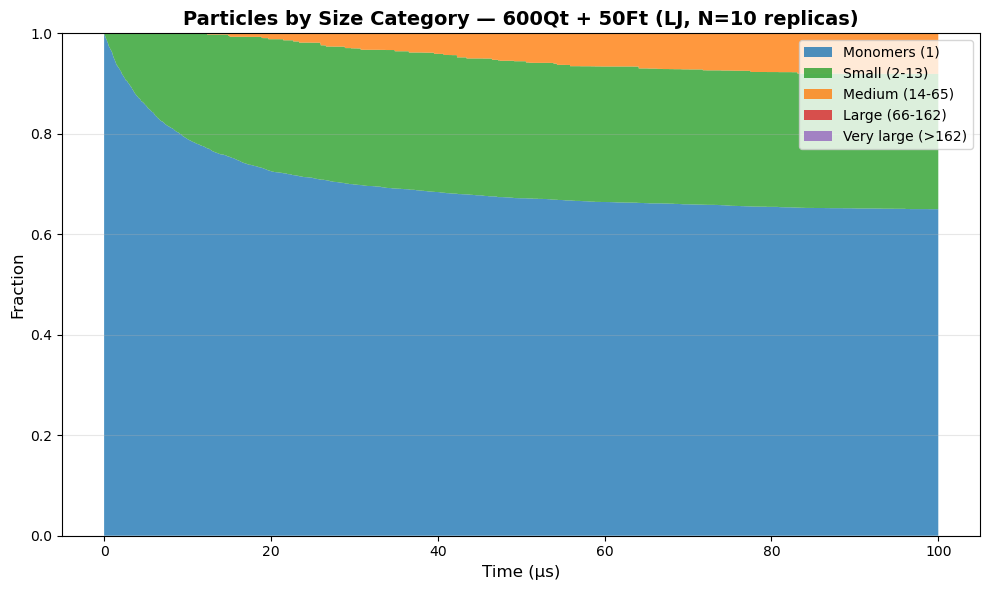

✓ Saved: Different_Particle_Ratios/Plots_Comparison_200Qt200Ft_200Qt400Ft_200Qt1000Ft_400Qt200Ft_600Qt50Ft_600Qt200Ft/size_categories_600_Qt_200_Ft.svg


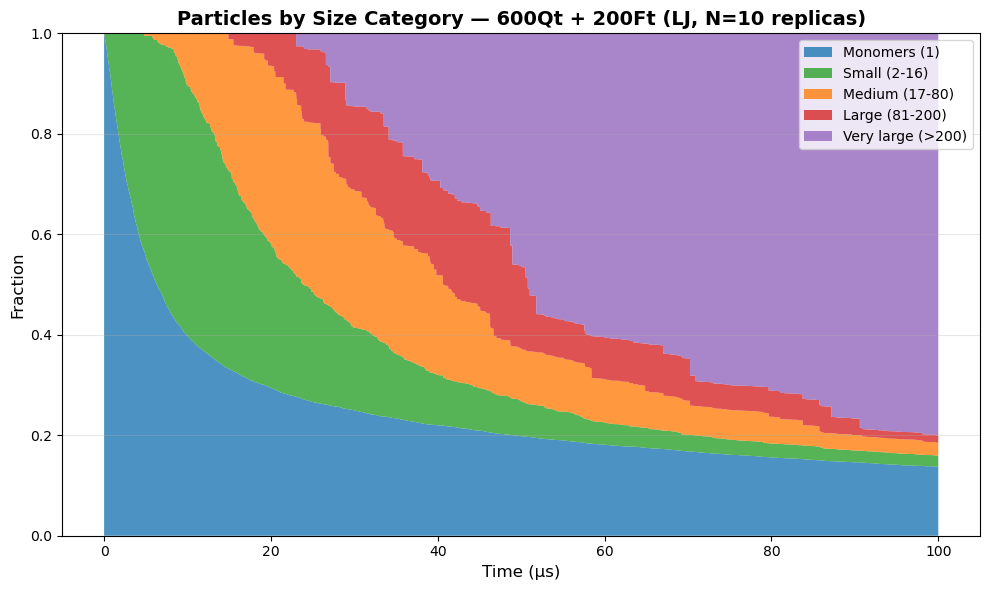

In [17]:
# Plot size categories for each ensemble (one figure per ensemble)
figs = plotting.plot_comparison_size_categories(
    comparison,
    save_dir=COMPARISON_PLOTS_DIR,
)

## 15. Save Comparison Data


In [ ]:
# Save comparison data for later use
ae.save_comparison_data(comparison, os.path.join(COMPARISON_PLOTS_DIR, "comparison_data"))

# To reload later:
# comparison = ae.load_comparison_data(os.path.join(COMPARISON_PLOTS_DIR, "comparison_data"))
